# Phase 4: Non-symbolic Models

This notebook implements four non-symbolic regression models for predicting `CURRENT_ENERGY_EFFICIENCY` from physical building characteristics.

**Models compared:**
1. **Random Forest** — bagging ensemble of decision trees
2. **XGBoost** — gradient boosting (sequential tree fitting)
3. **LightGBM** — gradient boosting with leaf-wise growth
4. **MLP (Neural Network)** — fully connected feedforward network

**Setup:**
- Same train/test split (`random_state=42`) and preprocessing pipeline as the Decision Tree notebook
- 10-fold cross-validation throughout (matches the project outline)
- RandomizedSearchCV with 30 iterations for hyperparameter tuning
- MLP uses StandardScaler in addition to median imputation (neural networks are sensitive to feature scale)

In [1]:
!pip install xgboost lightgbm

## 1. Setup & Data Load

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

df = pd.read_parquet('manchester_epc_phase3_final.parquet')
print(f"Dataset shape: {df.shape}")
print(f"Target range : {df['CURRENT_ENERGY_EFFICIENCY'].min()} - {df['CURRENT_ENERGY_EFFICIENCY'].max()}")
print(f"Target mean  : {df['CURRENT_ENERGY_EFFICIENCY'].mean():.2f} | std: {df['CURRENT_ENERGY_EFFICIENCY'].std():.2f}")

Dataset shape: (266470, 70)
Target range : 1 - 147
Target mean  : 68.94 | std: 11.65


## 2. Features & Target

In [5]:
TARGET = 'CURRENT_ENERGY_EFFICIENCY'
EXCLUDE = [TARGET, 'target_is_efficient']
feature_cols = [c for c in df.columns if c not in EXCLUDE]

X = df[feature_cols]
y = df[TARGET]

print(f"Total features: {X.shape[1]}")

Total features: 68


## 3. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test : {X_test.shape[0]:,} rows")

Train: 213,176 rows
Test : 53,294 rows


## 4. Preprocessing Pipelines

Two preprocessors are defined:
- **Tree-based** (RF, XGBoost, LightGBM): median imputation only — tree models are invariant to feature scale
- **MLP**: median imputation **and** StandardScaler — neural networks require scaled inputs to train effectively

In [9]:
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

preprocessor_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols)
], remainder='drop')

preprocessor_mlp = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols)
], remainder='drop')

print(f"Numeric features: {len(numeric_cols)}")

Numeric features: 68


## 5. Random Forest

**How it works:** Trains many decision trees in parallel, each on a random subset of the data and features (bagging). The final prediction is the average of all tree predictions. This reduces variance compared to a single tree.

In [11]:
# 5.1 Default Random Forest
rf_default = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_default_rmse = cross_val_score(rf_default, X_train, y_train, cv=10,
                                    scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_default_mae = cross_val_score(rf_default, X_train, y_train, cv=10,
                                   scoring='neg_mean_absolute_error', n_jobs=-1)

print("=== DEFAULT RANDOM FOREST ===")
print(f"CV RMSE: {-rf_default_rmse.mean():.3f} ± {rf_default_rmse.std():.3f}")
print(f"CV MAE : {-rf_default_mae.mean():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

=== DEFAULT RANDOM FOREST ===
CV RMSE: 5.693 ± 0.041
CV MAE : 3.758


In [13]:
# 5.2 Tuned Random Forest
rf_tune = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 10, 50],
    'model__min_samples_leaf': [1, 5, 20],
    'model__max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(rf_tune, rf_params, n_iter=30, cv=10,
                                 scoring='neg_root_mean_squared_error',
                                 n_jobs=-1, verbose=1, random_state=42, refit=True)
rf_search.fit(X_train, y_train)

print("\n=== TUNED RANDOM FOREST ===")
print(f"Best CV RMSE: {-rf_search.best_score_:.3f}")
print(f"Best params : {rf_search.best_params_}")

rf_tuned_mae = cross_val_score(rf_search.best_estimator_, X_train, y_train,
                                 cv=10, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"Tuned CV MAE: {-rf_tuned_mae.mean():.3f}")

Fitting 10 folds for each of 30 candidates, totalling 300 fits


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i


=== TUNED RANDOM FOREST ===
Best CV RMSE: 5.416
Best params : {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 20}


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Tuned CV MAE: 3.616


## 6. XGBoost

**How it works:** Builds trees sequentially, each new tree trained to correct the errors of the previous ones (gradient boosting). After many trees, the ensemble produces highly accurate predictions.

In [15]:
# 6.1 Default XGBoost
xgb_default = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

xgb_default_rmse = cross_val_score(xgb_default, X_train, y_train, cv=10,
                                     scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_default_mae = cross_val_score(xgb_default, X_train, y_train, cv=10,
                                    scoring='neg_mean_absolute_error', n_jobs=-1)

print("=== DEFAULT XGBOOST ===")
print(f"CV RMSE: {-xgb_default_rmse.mean():.3f} ± {xgb_default_rmse.std():.3f}")
print(f"CV MAE : {-xgb_default_mae.mean():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib

=== DEFAULT XGBOOST ===
CV RMSE: 5.564 ± 0.040
CV MAE : 3.822


In [17]:
# 6.2 Tuned XGBoost
xgb_tune = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

xgb_params = {
    'model__n_estimators': [200, 500, 1000],
    'model__max_depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__min_child_weight': [1, 5, 10]
}

xgb_search = RandomizedSearchCV(xgb_tune, xgb_params, n_iter=30, cv=10,
                                  scoring='neg_root_mean_squared_error',
                                  n_jobs=-1, verbose=1, random_state=42, refit=True)
xgb_search.fit(X_train, y_train)

print("\n=== TUNED XGBOOST ===")
print(f"Best CV RMSE: {-xgb_search.best_score_:.3f}")
print(f"Best params : {xgb_search.best_params_}")

xgb_tuned_mae = cross_val_score(xgb_search.best_estimator_, X_train, y_train,
                                  cv=10, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"Tuned CV MAE: {-xgb_tuned_mae.mean():.3f}")

Fitting 10 folds for each of 30 candidates, totalling 300 fits


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/comp


=== TUNED XGBOOST ===
Best CV RMSE: 5.354
Best params : {'model__subsample': 1.0, 'model__n_estimators': 500, 'model__min_child_weight': 10, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.85}


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Tuned CV MAE: 3.600


## 7. LightGBM

**How it works:** Same gradient boosting principle as XGBoost, but trees grow leaf-wise (deepening the most informative leaf rather than splitting level by level). This is faster and often competitive on large tabular datasets.

In [19]:
# 7.1 Default LightGBM
lgb_default = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

lgb_default_rmse = cross_val_score(lgb_default, X_train, y_train, cv=10,
                                     scoring='neg_root_mean_squared_error', n_jobs=-1)
lgb_default_mae = cross_val_score(lgb_default, X_train, y_train, cv=10,
                                    scoring='neg_mean_absolute_error', n_jobs=-1)

print("=== DEFAULT LIGHTGBM ===")
print(f"CV RMSE: {-lgb_default_rmse.mean():.3f} ± {lgb_default_rmse.std():.3f}")
print(f"CV MAE : {-lgb_default_mae.mean():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

=== DEFAULT LIGHTGBM ===
CV RMSE: 5.770 ± 0.044
CV MAE : 4.013


In [21]:
# 7.2 Tuned LightGBM
lgb_tune = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

lgb_params = {
    'model__n_estimators': [200, 500, 1000],
    'model__num_leaves': [31, 63, 127],
    'model__max_depth': [-1, 10, 20],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__min_child_samples': [5, 20, 50]
}

lgb_search = RandomizedSearchCV(lgb_tune, lgb_params, n_iter=30, cv=10,
                                  scoring='neg_root_mean_squared_error',
                                  n_jobs=-1, verbose=1, random_state=42, refit=True)
lgb_search.fit(X_train, y_train)

print("\n=== TUNED LIGHTGBM ===")
print(f"Best CV RMSE: {-lgb_search.best_score_:.3f}")
print(f"Best params : {lgb_search.best_params_}")

lgb_tuned_mae = cross_val_score(lgb_search.best_estimator_, X_train, y_train,
                                  cv=10, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"Tuned CV MAE: {-lgb_tuned_mae.mean():.3f}")

Fitting 10 folds for each of 30 candidates, totalling 300 fits


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib


=== TUNED LIGHTGBM ===
Best CV RMSE: 5.361
Best params : {'model__subsample': 0.7, 'model__num_leaves': 127, 'model__n_estimators': 1000, 'model__min_child_samples': 20, 'model__max_depth': -1, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Tuned CV MAE: 3.624


## 8. MLP (Neural Network)

**How it works:** A multi-layer perceptron with fully connected layers, ReLU activation, and Adam optimizer. Fundamentally different from tree-based models — represents the neural-network family in our comparison. Requires feature scaling, which is handled by the dedicated MLP preprocessor.

In [23]:
# 8.1 Default MLP
mlp_default = Pipeline([
    ('preprocessor', preprocessor_mlp),
    ('model', MLPRegressor(hidden_layer_sizes=(100,), max_iter=200,
                            random_state=42, early_stopping=True))
])

mlp_default_rmse = cross_val_score(mlp_default, X_train, y_train, cv=10,
                                     scoring='neg_root_mean_squared_error', n_jobs=-1)
mlp_default_mae = cross_val_score(mlp_default, X_train, y_train, cv=10,
                                    scoring='neg_mean_absolute_error', n_jobs=-1)

print("=== DEFAULT MLP ===")
print(f"CV RMSE: {-mlp_default_rmse.mean():.3f} ± {mlp_default_rmse.std():.3f}")
print(f"CV MAE : {-mlp_default_mae.mean():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


=== DEFAULT MLP ===
CV RMSE: 5.871 ± 0.059
CV MAE : 4.052


In [25]:
# 8.2 Tuned MLP
mlp_tune = Pipeline([
    ('preprocessor', preprocessor_mlp),
    ('model', MLPRegressor(max_iter=300, random_state=42, early_stopping=True))
])

mlp_params = {
    'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__learning_rate_init': [0.001, 0.01],
    'model__batch_size': [256, 512]
}

mlp_search = RandomizedSearchCV(mlp_tune, mlp_params, n_iter=20, cv=10,
                                  scoring='neg_root_mean_squared_error',
                                  n_jobs=-1, verbose=1, random_state=42, refit=True)
mlp_search.fit(X_train, y_train)

print("\n=== TUNED MLP ===")
print(f"Best CV RMSE: {-mlp_search.best_score_:.3f}")
print(f"Best params : {mlp_search.best_params_}")

mlp_tuned_mae = cross_val_score(mlp_search.best_estimator_, X_train, y_train,
                                  cv=10, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"Tuned CV MAE: {-mlp_tuned_mae.mean():.3f}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits

=== TUNED MLP ===
Best CV RMSE: 5.762
Best params : {'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (150, 100, 50), 'model__batch_size': 512, 'model__alpha': 0.01, 'model__activation': 'tanh'}
Tuned CV MAE: 3.946


## 9. Feature Importance (tree-based models)

MLP does not produce native feature importance scores. For neural network interpretation, permutation importance or SHAP would be used — these are reserved for the evaluation phase.

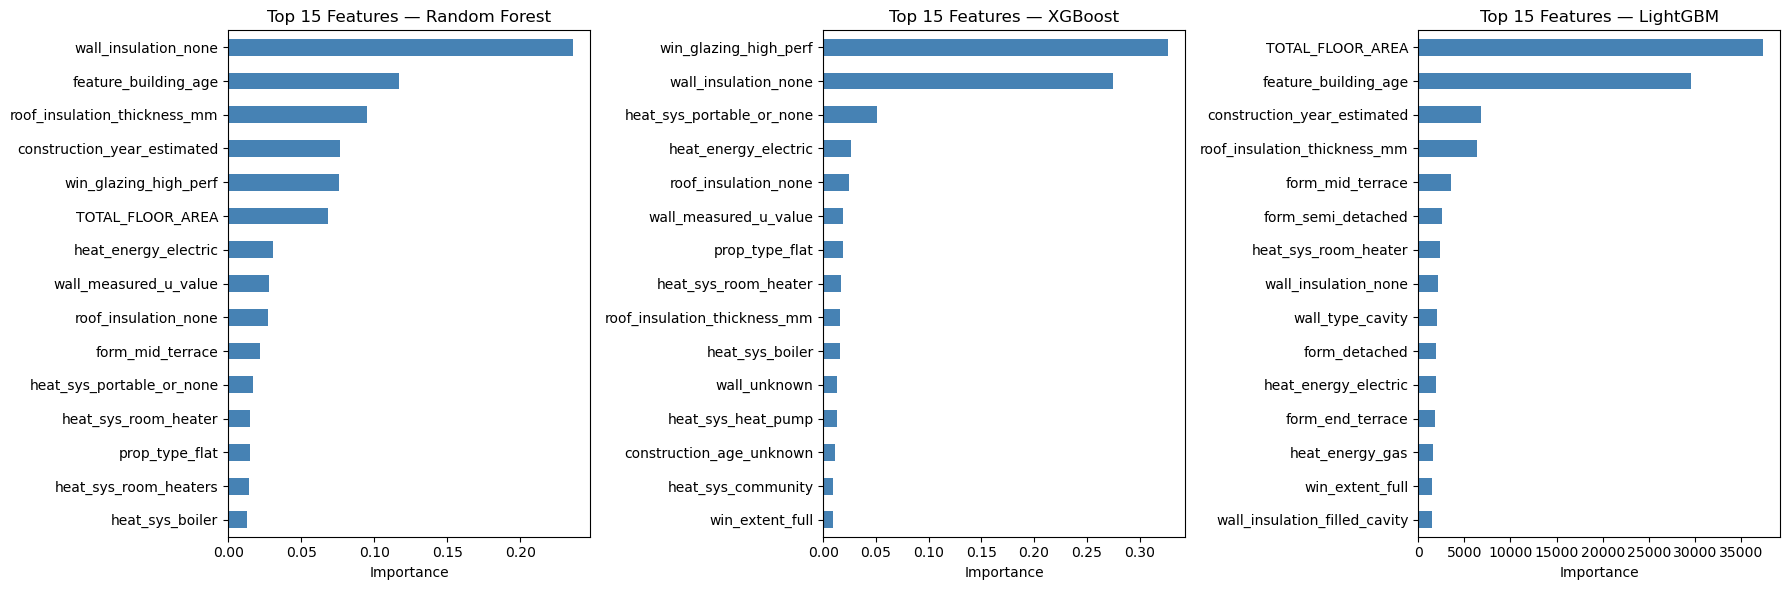

In [27]:
def get_importance(search_obj, feature_names):
    model = search_obj.best_estimator_.named_steps['model']
    importances = model.feature_importances_
    return pd.Series(importances, index=feature_names).sort_values(ascending=False)

all_feature_names = [
    name.split('__')[-1]
    for name in rf_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
]

rf_imp  = get_importance(rf_search,  all_feature_names).head(15)
xgb_imp = get_importance(xgb_search, all_feature_names).head(15)
lgb_imp = get_importance(lgb_search, all_feature_names).head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp, title in zip(
    axes,
    [rf_imp, xgb_imp, lgb_imp],
    ['Random Forest', 'XGBoost', 'LightGBM']
):
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 15 Features — {title}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('nonsymbolic_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Table

In [29]:
summary = pd.DataFrame({
    'Model': [
        'Random Forest (default)',
        'Random Forest (tuned)',
        'XGBoost (default)',
        'XGBoost (tuned)',
        'LightGBM (default)',
        'LightGBM (tuned)',
        'MLP (default)',
        'MLP (tuned)'
    ],
    'CV RMSE': [
        round(-rf_default_rmse.mean(), 3),
        round(-rf_search.best_score_, 3),
        round(-xgb_default_rmse.mean(), 3),
        round(-xgb_search.best_score_, 3),
        round(-lgb_default_rmse.mean(), 3),
        round(-lgb_search.best_score_, 3),
        round(-mlp_default_rmse.mean(), 3),
        round(-mlp_search.best_score_, 3)
    ],
    'CV MAE': [
        round(-rf_default_mae.mean(), 3),
        round(-rf_tuned_mae.mean(), 3),
        round(-xgb_default_mae.mean(), 3),
        round(-xgb_tuned_mae.mean(), 3),
        round(-lgb_default_mae.mean(), 3),
        round(-lgb_tuned_mae.mean(), 3),
        round(-mlp_default_mae.mean(), 3),
        round(-mlp_tuned_mae.mean(), 3)
    ]
})

print("=== PHASE 4 RESULTS (10-fold CV) ===")
print(summary.to_string(index=False))

summary.to_parquet('phase4_nonsymbolic_results.parquet')
summary.to_csv('phase4_nonsymbolic_results.csv', index=False)

=== PHASE 4 RESULTS (10-fold CV) ===
                  Model  CV RMSE  CV MAE
Random Forest (default)    5.693   3.758
  Random Forest (tuned)    5.416   3.616
      XGBoost (default)    5.564   3.822
        XGBoost (tuned)    5.354   3.600
     LightGBM (default)    5.770   4.013
       LightGBM (tuned)    5.361   3.624
          MLP (default)    5.871   4.052
            MLP (tuned)    5.762   3.946


## 11. Save Models for Phase 5 (Evaluation)

In [31]:
import joblib

joblib.dump(rf_search.best_estimator_,  'rf_best_model.pkl',  compress=3)
joblib.dump(xgb_search.best_estimator_, 'xgb_best_model.pkl', compress=3)
joblib.dump(lgb_search.best_estimator_, 'lgb_best_model.pkl', compress=3)
joblib.dump(mlp_search.best_estimator_, 'mlp_best_model.pkl', compress=3)

print("Four tuned models saved.")
print("Ready for Phase 5 (Evaluation).")

Four tuned models saved.
Ready for Phase 5 (Evaluation).
